# CS 584-A: Natural Language Processing - Homework 1
**Sentiment analysis on Amazon product reviews: feature extraction and text classification**

**Student:** [YOUR NAME] &nbsp;&nbsp; **CWID:** [YOUR CWID]

---
### Task definition (stated up front, as the assignment requires)
* **Problem solved:** **binary** sentiment classification (positive vs. negative) from free-text reviews.
* **How the class labels were prepared** (from the 1-5 `overall` rating):
  * rating **4 or 5 -> positive (label 1)**
  * rating **1 or 2 -> negative (label 0)**
  * rating **3 (neutral) -> discarded**
* **Pipeline:** load -> preprocess -> 80/10/10 split -> statistics -> count-based word vectors (co-occurrence + SVD) -> GloVe word vectors -> review embeddings (average of word vectors) -> Logistic Regression (L2) and a Neural Network -> evaluation on the test set.
* **Note on dataset size:** the handout says 4,195 products; the file provided on Canvas actually contains **4,915 rows**. All numbers in this notebook are computed from the file as provided.

## 0. Setup
This cell imports every library used in the notebook and fixes the random seeds so that every run produces the same numbers.
* `numpy` / `pandas`: arrays, matrices and tabular data.
* `matplotlib` / `seaborn`: plots.
* `nltk`: English stop-word list.
* `sklearn`: train/test split, `TruncatedSVD` (SVD), `StandardScaler`, `LogisticRegression`, `MLPClassifier` (neural network) and the evaluation metrics.
* `gensim` is imported later, inside `load_embedding_model()`, to download GloVe.

If you run this on a fresh machine / Colab, install the dependencies once with `pip install gensim nltk scikit-learn pandas matplotlib seaborn`.

In [1]:
import os, re, string, random, copy, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, log_loss, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

warnings.filterwarnings("ignore", category=FutureWarning)   # keep the output clean (sklearn API deprecation notices only)

SEED = 42                      # one global seed -> reproducible results
random.seed(SEED)
np.random.seed(SEED)

sns.set_style("whitegrid")     # consistent plot style
plt.rcParams["figure.dpi"] = 110

nltk.download("stopwords", quiet=True)   # one-off download of the stop-word list
print("Setup complete.")

Setup complete.


# Task 1: Extracting features (60 points)
## 1. Data preparation (20 points)
### 1) Data preprocessing (10 points)

**Step A - load the data.** We read the CSV (columns: `overall` = star rating, `reviewText` = free text), look at its size and check for missing values.

In [2]:
# The CSV is expected next to the notebook (the second path is only a fallback for the grader's/my environment)
DATA_PATH = next(p for p in ["amazon_reviews.csv", "/mnt/user-data/uploads/amazon_reviews.csv"] if os.path.exists(p))

df_raw = pd.read_csv(DATA_PATH)
print("Raw shape:", df_raw.shape)
print("\nMissing values per column:\n", df_raw.isna().sum())
print("\nFirst rows:")
df_raw.head()

Raw shape: (4915, 2)

Missing values per column:
 overall       0
reviewText    1
dtype: int64

First rows:


,overall,reviewText
0,4,No issues.
1,5,"Purchased this for my device, it worked as adv..."
2,4,it works as expected. I should have sprung for...
3,5,This think has worked out great.Had a diff. br...
4,5,"Bought it with Retail Packaging, arrived legit..."


**Step B - clean and label.**
* One review has no text (`NaN`), so it cannot be used and is dropped.
* The original 5-class rating distribution is plotted first: it is **strongly imbalanced toward 5 stars**, which will matter for the choice of evaluation metrics later.
* Binary labels are created: 4-5 -> 1 (positive), 1-2 -> 0 (negative), 3 -> dropped.

Rows after dropping missing text: 4914 (removed 1)


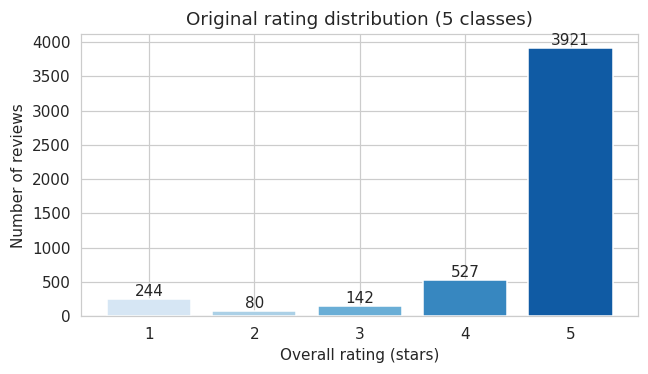


Neutral (3-star) reviews discarded: 142
Binary label counts (0 = negative, 1 = positive):
label
0     324
1    4448
Name: count, dtype: int64


In [3]:
# 1) drop rows without review text
df = df_raw.dropna(subset=["reviewText"]).copy()
print(f"Rows after dropping missing text: {len(df)} (removed {len(df_raw) - len(df)})")

# 2) plot the original 5-class rating distribution
rating_counts = df["overall"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(rating_counts.index.astype(str), rating_counts.values, color=sns.color_palette("Blues", 5))
ax.bar_label(bars)
ax.set_xlabel("Overall rating (stars)"); ax.set_ylabel("Number of reviews")
ax.set_title("Original rating distribution (5 classes)")
plt.tight_layout(); plt.show()

# 3) build binary labels: 4,5 -> 1 (positive); 1,2 -> 0 (negative); 3 (neutral) -> discarded
n_before = len(df)
df = df[df["overall"] != 3].copy()
df["label"] = (df["overall"] >= 4).astype(int)
print(f"\nNeutral (3-star) reviews discarded: {n_before - len(df)}")
print("Binary label counts (0 = negative, 1 = positive):")
print(df["label"].value_counts().sort_index())

**Step C - text preprocessing.** The function `preprocess()` performs exactly what the assignment lists, in this order:
1. **lower-case** everything;
2. **remove punctuation** - apostrophes are deleted (so `don't` -> `dont`), every other punctuation mark is replaced by a space (so `well-made` -> `well made` instead of the glued word `wellmade`);
3. **remove numbers**;
4. **tokenize** by whitespace;
5. **remove stop-words** using NLTK's English list (the list is also added in its apostrophe-free form so that `dont`, `isnt`, ... are removed too).

Reviews that end up with zero tokens are dropped (none are expected). Note that NLTK's list also removes negations such as *not* / *no*; this follows the assignment instructions, and is revisited in the discussion.

In [4]:
STOPWORDS = set(stopwords.words("english"))
STOPWORDS |= {w.replace("'", "") for w in STOPWORDS}          # e.g. "don't" -> "dont" (matches our apostrophe-free text)

# translation table: every punctuation character EXCEPT the apostrophe becomes a space
PUNCT_TO_SPACE = str.maketrans({c: " " for c in string.punctuation if c != "'"})

def preprocess(text):
    """Raw review string -> list of cleaned tokens."""
    text = text.lower()                                        # (i)   lower-case
    text = text.replace("'", "").replace("\u2019", "")         # delete straight and curly apostrophes
    text = text.translate(PUNCT_TO_SPACE)                      # (ii)  remove punctuation
    text = re.sub(r"\d+", " ", text)                           # (ii)  remove numbers
    tokens = text.split()                                      # (iii) tokenize on whitespace
    return [t for t in tokens if t not in STOPWORDS]           # (ii)  remove stop-words

df["tokens"] = df["reviewText"].apply(preprocess)

# Before / after example
example = df.iloc[3]
print("RAW   :", example["reviewText"][:200])
print("TOKENS:", example["tokens"][:25])

# drop reviews that became empty after cleaning
n_empty = (df["tokens"].str.len() == 0).sum()
df = df[df["tokens"].str.len() > 0].reset_index(drop=True)
print(f"\nEmpty reviews removed: {n_empty}   |   Final number of reviews: {len(df)}")

RAW   : This think has worked out great.Had a diff. bran 64gb card and if went south after 3 months.This one has held up pretty well since I had my S3, now on my Note3.*** update 3/21/14I've had this for a fe
TOKENS: ['think', 'worked', 'great', 'diff', 'bran', 'gb', 'card', 'went', 'south', 'months', 'one', 'held', 'pretty', 'since', 'note', 'update', 'months', 'zero', 'issues', 'since', 'transferred', 'note', 'note', 'card', 'reliable']

Empty reviews removed: 0   |   Final number of reviews: 4772


### 2) Data split (5 points)
The data is split **80 % / 10 % / 10 %** into train / validation (development) / test. The split is **stratified by label** (and uses a fixed seed), so that the rare negative class appears in the same proportion in all three parts - with only ~7 % negatives, a purely random split could leave very few negatives in the validation or test set. Two successive calls to `train_test_split` are used: first 80/20, then the 20 % is halved into validation and test.

In [5]:
train_df, temp_df = train_test_split(df, test_size=0.20, stratify=df["label"], random_state=SEED)
dev_df, test_df   = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED)

for name, part in [("train", train_df), ("dev", dev_df), ("test", test_df)]:
    print(f"{name:5s}: {len(part):5d} reviews  ({len(part)/len(df):.1%})")

train:  3817 reviews  (80.0%)
dev  :   477 reviews  (10.0%)
test :   478 reviews  (10.0%)


### 3) Data statistics (5 points)
We report, per split: number of samples, number of positive / negative reviews (and % positive), and the **minimum / average / median / maximum number of tokens per review** (after preprocessing). We also report corpus-level statistics (vocabulary size, total tokens) and plot the class distribution per split and the review-length distribution.

,# samples,# positive,# negative,% positive,min tokens,avg tokens,median tokens,max tokens
Split,,,,,,,,
Train,3817,3558,259,93.21,1,25.16,16,775
Dev,477,445,32,93.29,1,23.10,16,226
Test,478,445,33,93.10,1,23.39,16,141
All,4772,4448,324,93.21,1,24.78,16,775



Total tokens: 118,228 | Vocabulary size (distinct tokens): 7,402


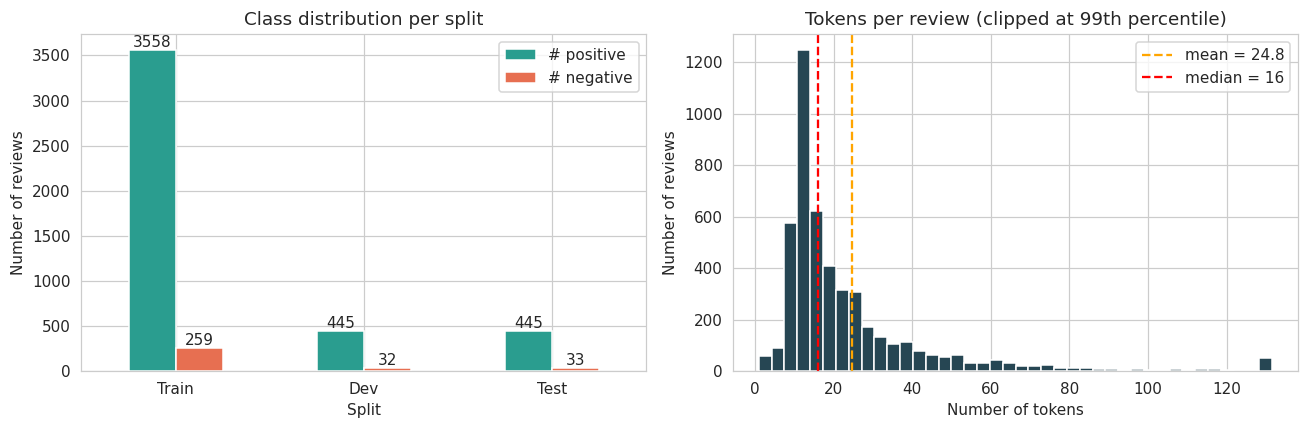

In [6]:
rows = []
for name, part in [("Train", train_df), ("Dev", dev_df), ("Test", test_df), ("All", df)]:
    lens = part["tokens"].str.len()
    rows.append({"Split": name,
                 "# samples": len(part),
                 "# positive": int((part["label"] == 1).sum()),
                 "# negative": int((part["label"] == 0).sum()),
                 "% positive": round(100 * part["label"].mean(), 2),
                 "min tokens": int(lens.min()),
                 "avg tokens": round(lens.mean(), 2),
                 "median tokens": int(lens.median()),
                 "max tokens": int(lens.max())})
stats_df = pd.DataFrame(rows).set_index("Split")
display(stats_df)

all_tokens = [t for toks in df["tokens"] for t in toks]
print(f"\nTotal tokens: {len(all_tokens):,} | Vocabulary size (distinct tokens): {len(set(all_tokens)):,}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# (a) class counts per split
plot_df = stats_df.loc[["Train", "Dev", "Test"], ["# positive", "# negative"]]
plot_df.plot(kind="bar", ax=axes[0], color=["#2a9d8f", "#e76f51"], rot=0)
for c in axes[0].containers: axes[0].bar_label(c)
axes[0].set_title("Class distribution per split"); axes[0].set_ylabel("Number of reviews")
# (b) review length distribution (clipped at the 99th percentile so the long tail does not squash the plot)
lens_all = df["tokens"].str.len()
axes[1].hist(lens_all.clip(upper=lens_all.quantile(0.99)), bins=40, color="#264653")
axes[1].axvline(lens_all.mean(), color="orange", ls="--", label=f"mean = {lens_all.mean():.1f}")
axes[1].axvline(lens_all.median(), color="red", ls="--", label=f"median = {lens_all.median():.0f}")
axes[1].set_title("Tokens per review (clipped at 99th percentile)")
axes[1].set_xlabel("Number of tokens"); axes[1].set_ylabel("Number of reviews"); axes[1].legend()
plt.tight_layout(); plt.show()

**Analysis of the data statistics**

* **Size and splits.** After dropping 1 empty review and 142 neutral reviews, 4,772 reviews remain: 3,817 train / 477 dev / 478 test (80 / 10 / 10 %).
* **Strong class imbalance.** 4,448 reviews (93.2 %) are positive and only 324 (6.8 %) are negative. The stratified split kept this ratio almost identical in every part (93.21 % / 93.29 % / 93.10 % positive), so the three sets are comparable.
* **Short, right-skewed reviews.** After preprocessing a review has on average 24.8 tokens, but the median is only 16, the minimum is 1 (e.g. "No issues." -> `issues`) and the maximum is 775: most reviews are one or two sentences, a few are very long. The corpus has 118,228 tokens and 7,402 distinct words.
* **Consequences for the rest of the assignment.** (1) *Accuracy is misleading*: a classifier that always answers "positive" already scores 93.1 % on the test set, so we also report precision/recall/F1/AUC and use macro-F1 for model selection. (2) The validation and test sets contain only **32 and 33 negative reviews**, so every negative-class metric is noisy (one review changes the negative recall by about 3 percentage points). (3) Very short reviews give noisy averaged embeddings, because the average is taken over only a handful of words.

## 2. Representation of texts: word vectors (40 points)
### 1) Count-based word vectors with a co-occurrence matrix (20 points)

The corpus passed to the functions below is a **list of reviews, each review being a list of tokens**. The co-occurrence matrix is label-free (unsupervised), so it is built from all cleaned reviews.

**a) `get_vacab(corpus)`** (5 pts) returns `corpus_words`: the sorted list of all distinct words. A list comprehension flattens the corpus, `set()` removes duplicates and `sorted()` orders the result (the function name `get_vacab` is kept exactly as written in the handout).

In [7]:
def get_vacab(corpus):
    """Return the sorted list of all distinct words in the corpus.

    corpus: list of reviews, each review a list of tokens.
    """
    # nested list comprehension flattens the corpus; set() de-duplicates; sorted() gives a deterministic order
    corpus_words = sorted(set([word for review in corpus for word in review]))
    return corpus_words

# --- quick unit test on the toy corpus of the lecture (slides 12 and 15) ---
toy_corpus = [["i", "like", "deep", "learning", "."],
              ["i", "like", "nlp", "."],
              ["i", "enjoy", "flying", "."]]
print("Toy vocabulary:", get_vacab(toy_corpus))

Toy vocabulary: ['.', 'deep', 'enjoy', 'flying', 'i', 'learning', 'like', 'nlp']


**b) `compute_co_occurrence_matrix(corpus, window_size=4)`** (5 pts) returns `M` and `word2index`.
* `word2index` maps each word of the vocabulary to a row/column index.
* `M[i, j]` counts how many times word *j* appears within `window_size` positions **before or after** word *i* (the centre word). Windows never cross review boundaries because each review is processed separately.
* `M` is a dense `numpy` array (`float32` to halve memory: ~9.6k x 9.6k entries).

*Sanity check:* with `window_size=1` on the lecture's toy corpus the result must reproduce the matrix on slide 12 (e.g. `I-like = 2`, `I-enjoy = 1`, `deep-learning = 1`).

In [8]:
def compute_co_occurrence_matrix(corpus, window_size=4):
    """Build the symmetric word-word co-occurrence count matrix.

    Returns
    -------
    M          : np.ndarray (V, V)  co-occurrence counts
    word2index : dict               word -> row/column index in M
    """
    corpus_words = get_vacab(corpus)                                   # sorted vocabulary (part a)
    word2index = {w: i for i, w in enumerate(corpus_words)}            # word -> index
    V = len(corpus_words)
    M = np.zeros((V, V), dtype=np.float32)                             # V x V matrix of zeros

    for review in corpus:                                              # process each review separately
        idx = [word2index[w] for w in review]                          # review as a list of indices
        n = len(idx)
        for pos, center in enumerate(idx):                             # every token is the centre word once
            lo = max(0, pos - window_size)                             # left edge of the window
            hi = min(n, pos + window_size + 1)                         # right edge (exclusive)
            for j in range(lo, hi):
                if j != pos:                                           # a word does not co-occur with itself
                    M[center, idx[j]] += 1                             # count the context word
    return M, word2index

# --- unit test against slide 12 of the lecture ---
M_toy, w2i_toy = compute_co_occurrence_matrix(toy_corpus, window_size=1)
toy_df = pd.DataFrame(M_toy.astype(int), index=sorted(w2i_toy, key=w2i_toy.get), columns=sorted(w2i_toy, key=w2i_toy.get))
display(toy_df)
assert toy_df.loc["i", "like"] == 2 and toy_df.loc["i", "enjoy"] == 1 and toy_df.loc["deep", "learning"] == 1
assert np.allclose(M_toy, M_toy.T), "co-occurrence matrix must be symmetric"
print("Toy test passed: matrix matches the lecture example and is symmetric.")

,.,deep,enjoy,flying,i,learning,like,nlp
.,0,0,0,1,0,1,0,1
deep,0,0,0,0,0,1,1,0
enjoy,0,0,0,1,1,0,0,0
flying,1,0,1,0,0,0,0,0
i,0,0,1,0,0,0,2,0
learning,1,1,0,0,0,0,0,0
like,0,1,0,0,2,0,0,1
nlp,1,0,0,0,0,0,1,0


Toy test passed: matrix matches the lecture example and is symmetric.


In [9]:
# Build the real co-occurrence matrix on the review corpus (default window of 4 words on each side)
corpus = df["tokens"].tolist()
corpus_words = get_vacab(corpus)
M_co, word2index_co = compute_co_occurrence_matrix(corpus, window_size=4)

print("Vocabulary size:", len(corpus_words))
print("Co-occurrence matrix shape:", M_co.shape, "| memory: %.0f MB" % (M_co.nbytes / 1e6))
print("Non-zero entries: %.2f%%  (the matrix is very sparse)" % (100 * np.count_nonzero(M_co) / M_co.size))

Vocabulary size: 7402
Co-occurrence matrix shape: (7402, 7402) | memory: 219 MB
Non-zero entries: 0.75%  (the matrix is very sparse)


**c) `reduce_to_k_dim(M, k=2)`** (5 pts) performs dimensionality reduction with `sklearn.decomposition.TruncatedSVD` (`n_iter = 10`, as required; in scikit-learn the parameter is spelled `n_iter`). `fit_transform` keeps the top-*k* singular components and returns `U_k * Sigma_k`, i.e. one *k*-dimensional dense embedding per row of `M`. It also prints the share of the matrix variance retained. The default `k=2` is used for plotting; the same function is reused later with `k=128`.

In [10]:
def reduce_to_k_dim(M, k=2):
    """Truncated-SVD dimensionality reduction.

    M : np.ndarray (n_words, n_features)
    k : number of components to keep
    Returns M_reduced : np.ndarray (n_words, k)
    """
    svd = TruncatedSVD(n_components=k, n_iter=10, random_state=SEED)   # n_iter=10 as required by the handout
    M_reduced = svd.fit_transform(M)                                    # top-k components -> k-dim embeddings
    print(f"Reduced {M.shape} -> {M_reduced.shape} | variance retained: {svd.explained_variance_ratio_.sum():.2%}")
    return M_reduced

M_co_2d = reduce_to_k_dim(M_co, k=2)

Reduced (7402, 7402) -> (7402, 2) | variance retained: 73.98%


**d) `plot_embeddings(M_reduced, word2index, words_to_plot)`** (5 pts) draws a scatter plot of the 2-D embeddings of the requested words and labels each point. Words that are not in `word2index` are skipped with a warning. We call it for the ten words required by the handout.

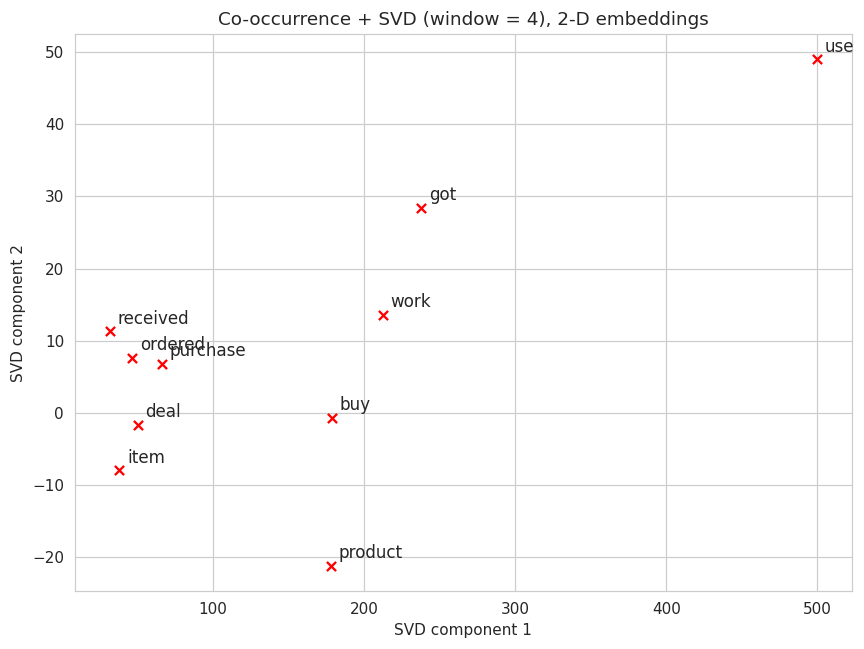

In [11]:
def plot_embeddings(M_reduced, word2index, words_to_plot, title=None):
    """Scatter plot of 2-D embeddings for the words in words_to_plot."""
    fig, ax = plt.subplots(figsize=(8, 6))
    for word in words_to_plot:
        if word not in word2index:                                      # guard: word missing from the vocabulary
            print(f"Warning: '{word}' not in word2index - skipped")
            continue
        x, y = M_reduced[word2index[word]]                              # 2-D coordinates of this word
        ax.scatter(x, y, marker="x", color="red")                       # the point
        ax.annotate(word, (x, y), textcoords="offset points", xytext=(5, 5), fontsize=11)   # its label
    ax.set_xlabel("SVD component 1"); ax.set_ylabel("SVD component 2")
    if title: ax.set_title(title)
    plt.tight_layout(); plt.show()

words_to_plot = ["purchase", "buy", "work", "got", "ordered", "received", "product", "item", "deal", "use"]
plot_embeddings(M_co_2d, word2index_co, words_to_plot, title="Co-occurrence + SVD (window = 4), 2-D embeddings")

**Observations on the co-occurrence + SVD plot**

* The 2 SVD components retain 74 % of the matrix variance, but the picture is dominated by **word frequency**, not meaning. Component 1 orders the ten words almost exactly by how often they occur in the corpus: *use* (1,087 occurrences) is far to the right (x ~ 500), *got* (546), *product* (526), *work* (463) and *buy* (453) lie in the middle (x ~ 180-240), while the rarest words *purchase* (168), *deal* (125), *item* (119), *ordered* (102) and *received* (74) sit at the far left (x ~ 30-65). Frequent words co-occur with many more words, so their raw-count rows are much larger and the first singular direction mostly captures this magnitude. This is exactly the weakness the lecture points out ("running an SVD on raw counts doesn't work well"; remedies: scaling/clipping the counts, ignoring function words, PMI-style weighting).
* Some meaningful structure is visible: the order-fulfilment words *ordered*, *received* and *purchase* form a loose group on the left. But near-synonyms are not close: *product* and *item* are far apart (they differ in frequency, 526 vs. 119), and *buy* is far from *purchase*.

### 2) Prediction-based word vectors from GloVe (20 points)
**a) Load GloVe** (5 pts). We use the provided `load_embedding_model()` unchanged: it downloads `glove-wiki-gigaword-200` (400,000 words, 200 dimensions, pre-trained on Wikipedia + Gigaword) through `gensim`. The first call downloads ~250 MB and takes a couple of minutes; afterwards it is loaded from the local cache.

In [12]:
def load_embedding_model():
    """ Load GloVe Vectors
        Return:
            wv_from_bin: All 400000 embeddings, each lengh 200
    """
    import gensim.downloader as api
    wv_from_bin = api.load("glove-wiki-gigaword-200")
    print("Loaded vocab size %i" % len(list(wv_from_bin.index_to_key)))
    return wv_from_bin

# -----------------------------------
# Run Cell to Load Word Vectors
# Note: This will take a couple minutes
# -----------------------------------
wv_from_bin = load_embedding_model()

Loaded vocab size 400000


**b) Select the GloVe vectors of our vocabulary** (5 pts). `get_matrix_of_vectors(wv_from_bin, required_words)` is the provided function (with `numpy` imported, and a `set` used for the membership test to make it fast - behaviour unchanged). It builds a matrix `M` containing (1) 10,000 randomly chosen GloVe words (fixed seed 225) and (2) **every word of our review vocabulary** (`required_words = corpus_words` from part 1a) that exists in GloVe. Review words absent from GloVe (typos, brand names) are skipped. `word2ind` maps word -> row of `M`.

In [13]:
def get_matrix_of_vectors(wv_from_bin, required_words):
    """ Put the GloVe vectors into a matrix M.
        Param:
            wv_from_bin: KeyedVectors object; the 400000 GloVe vectors loaded from file
            required_words: words from OUR corpus that must be in the matrix
        Return:
            M: numpy matrix shape (num words, 200) containing the vectors
            word2ind: dictionary mapping each word to its row number in M
    """
    words = list(wv_from_bin.index_to_key)
    print("Shuffling words ...")
    random.seed(225)                               # same seed as in the handout
    random.shuffle(words)
    words = words[:10000]                          # keep 10,000 random GloVe words
    words_set = set(words)                         # O(1) membership test (the list version is O(n))
    print("Putting %i words into word2ind and matrix M..." % len(words))
    word2ind = {}
    M = []
    curInd = 0
    for w in words:                                # 1) the 10,000 random words
        try:
            M.append(wv_from_bin.get_vector(w))
            word2ind[w] = curInd
            curInd += 1
        except KeyError:
            continue
    for w in required_words:                       # 2) all words of our review corpus
        if w in words_set:                         #    (skip if already added above)
            continue
        try:
            M.append(wv_from_bin.get_vector(w))
            word2ind[w] = curInd
            curInd += 1
        except KeyError:                           #    word not in GloVe -> skipped
            continue
    M = np.stack(M)
    print("Done.")
    return M, word2ind

M_glove, word2ind_glove = get_matrix_of_vectors(wv_from_bin, corpus_words)
in_glove = sum(w in word2ind_glove for w in corpus_words)
print("GloVe matrix shape:", M_glove.shape)
print(f"Review-vocabulary words found in GloVe: {in_glove} / {len(corpus_words)} ({in_glove/len(corpus_words):.1%})")

Shuffling words ...
Putting 10000 words into word2ind and matrix M...
Done.
GloVe matrix shape: (16267, 200)
Review-vocabulary words found in GloVe: 6412 / 7402 (86.6%)


**c) Reduce the GloVe vectors to 2 dimensions** (5 pts) with the `reduce_to_k_dim()` function implemented in part 1c (200 -> 2 dimensions).

In [14]:
M_glove_2d = reduce_to_k_dim(M_glove, k=2)

Reduced (16267, 200) -> (16267, 2) | variance retained: 12.41%


**d) Plot and compare** (5 pts). The same `plot_embeddings()` function and the same word list are used. To support the comparison with numbers (not only with the 2-D pictures, which discard most of the information), we also print the **cosine similarity in the full original spaces** for a few word pairs: raw co-occurrence rows (V dimensions) vs. GloVe (200 dimensions).

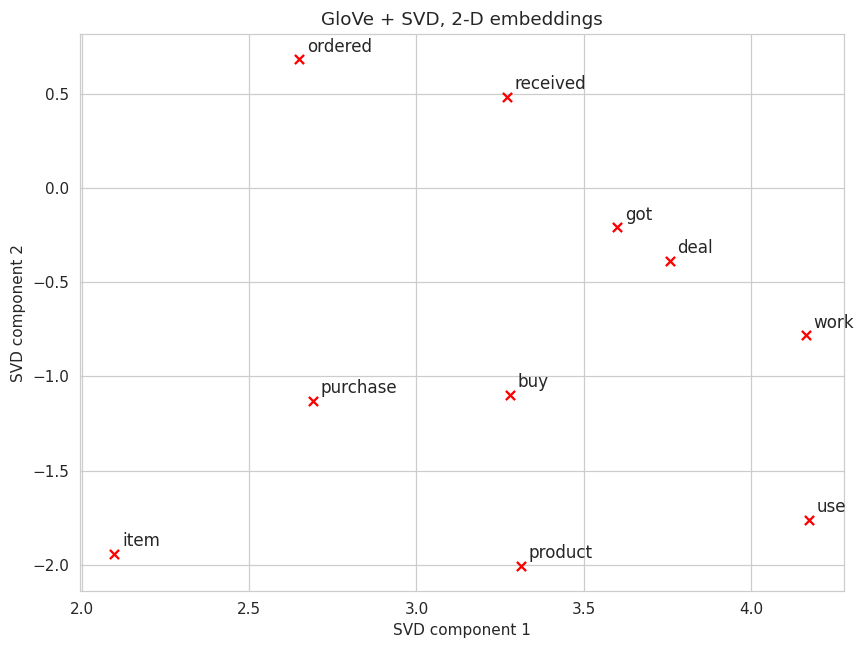

,co-occurrence (raw counts),GloVe (200-d)
pair,,
buy - purchase,0.808,0.814
product - item,0.819,0.434
ordered - received,0.758,0.409
work - use,0.872,0.584
buy - deal,0.668,0.557
got - received,0.757,0.549


In [15]:
plot_embeddings(M_glove_2d, word2ind_glove, words_to_plot, title="GloVe + SVD, 2-D embeddings")

# --- numeric comparison in the FULL spaces (cosine similarity) ---
def cos(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))

pairs = [("buy", "purchase"), ("product", "item"), ("ordered", "received"), ("work", "use"), ("buy", "deal"), ("got", "received")]
rows = []
for a, b in pairs:
    rows.append({"pair": f"{a} - {b}",
                 "co-occurrence (raw counts)": round(cos(M_co[word2index_co[a]], M_co[word2index_co[b]]), 3),
                 "GloVe (200-d)": round(cos(M_glove[word2ind_glove[a]], M_glove[word2ind_glove[b]]), 3)})
display(pd.DataFrame(rows).set_index("pair"))

**Comparison of the two plots (count-based vs. GloVe) and findings**

1. **What the axes capture.** In the co-occurrence plot the x-axis spans ~30 to ~500 and mainly encodes frequency (see above). The GloVe points occupy a compact region (x ~ 2.1-4.2, y ~ -2.0 to 0.7) with no such frequency gradient, and the layout follows **meaning and usage**:
   * *ordered* and *received* are together at the top (order-fulfilment events);
   * *purchase* and *buy* are neighbours at the same height (y ~ -1.1);
   * *work* and *use* are both at the far right (functional "usage" verbs);
   * *product* and *item* are both at the bottom (y ~ -2.0 and -1.9, the "object" nouns).

   These groups match intuition better than the co-occurrence plot, where *product* and *item* were far apart.
2. **Numeric evidence in the full spaces** (table above). With raw counts almost every pair is very similar (cosine 0.67-0.87; the highest, 0.87, is for *work*-*use*), i.e. the representation barely discriminates because frequency dominates every row. With GloVe the near-synonyms *buy*-*purchase* stand out clearly (0.81 versus 0.41-0.58 for the other pairs). GloVe is not perfect either: *product*-*item* (0.43) is lower than one would expect for near-synonyms.
3. **Why they differ.** The co-occurrence vectors are learned only from our small corpus (118k tokens; just 0.75 % of the matrix entries are non-zero), so counts for rarer words are noisy. GloVe was pre-trained on about 6 billion tokens of Wikipedia and Gigaword and models *ratios* of co-occurrence probabilities, which makes it robust to frequency and gives dense, semantically organised vectors even for rare words.
4. **Trade-offs.** GloVe is general-domain, not trained on product reviews, so domain-specific usage can be missed, and 990 of our 7,402 word types (13.4 %; mostly typos, brand names and model numbers) have no GloVe vector (they cover only 1.5 % of all tokens, so 98.5 % of tokens are covered). The count-based vectors cover the whole vocabulary and are specific to this domain, but are far noisier here.
5. **Caution.** A 2-D projection keeps little information (74 % of the variance for co-occurrence, but only 12.4 % for GloVe), so distances in these pictures are a rough guide; the cosine similarities in the full space are more reliable.

**Conclusion:** on this small review corpus, pre-trained GloVe vectors give a more meaningful, frequency-robust representation than raw co-occurrence counts + SVD, consistent with the lecture. This motivates using GloVe for the classification task.

# Task 2: Sentiment classification algorithms (40 points)
## 3. Perform sentiment analysis with classification
### 1) Review embeddings (5 points)
As in part 2)c, `reduce_to_k_dim()` is applied to the GloVe matrix, this time keeping **128 dimensions** (200 -> 128). Every word of our vocabulary that is in GloVe now has a 128-d vector.

A **review embedding** is the **average of the 128-d vectors of the words in the review** (`get_review_embedding`). Words without a vector are ignored; a review with no covered word would get the zero vector (we report how many tokens/reviews are affected). `get_review_embeddings` applies the function to a whole list of reviews.

Finally the features are **standardized** (zero mean, unit variance per dimension) using statistics computed on the **training set only**, then applied to validation and test - this avoids information leaking from the evaluation data and helps both models converge.

In [16]:
glove_128 = reduce_to_k_dim(M_glove, k=128)          # (n_words, 128) word vectors

def get_review_embedding(tokens, word_vectors, word2ind):
    """Average the word vectors of one review (words without a vector are skipped)."""
    vecs = [word_vectors[word2ind[t]] for t in tokens if t in word2ind]
    if len(vecs) == 0:                                # no word covered -> zero vector
        return np.zeros(word_vectors.shape[1])
    return np.mean(vecs, axis=0)                      # element-wise mean over the words

def get_review_embeddings(token_lists, word_vectors, word2ind):
    """Review embeddings for a list of tokenized reviews -> array (n_reviews, 128)."""
    return np.vstack([get_review_embedding(t, word_vectors, word2ind) for t in token_lists])

X_train_raw = get_review_embeddings(train_df["tokens"], glove_128, word2ind_glove)
X_dev_raw   = get_review_embeddings(dev_df["tokens"],   glove_128, word2ind_glove)
X_test_raw  = get_review_embeddings(test_df["tokens"],  glove_128, word2ind_glove)
y_train, y_dev, y_test = train_df["label"].values, dev_df["label"].values, test_df["label"].values

# coverage report
tok_total = sum(len(t) for t in df["tokens"])
tok_cov   = sum(sum(w in word2ind_glove for w in t) for t in df["tokens"])
no_cov    = sum(all(w not in word2ind_glove for w in t) for t in df["tokens"])
print(f"Tokens covered by GloVe: {tok_cov/tok_total:.2%} | reviews with NO covered word: {no_cov}")

# standardize with TRAIN statistics only
scaler = StandardScaler().fit(X_train_raw)
X_train, X_dev, X_test = scaler.transform(X_train_raw), scaler.transform(X_dev_raw), scaler.transform(X_test_raw)
print("Feature matrices:", X_train.shape, X_dev.shape, X_test.shape)

Reduced (16267, 200) -> (16267, 128) | variance retained: 87.86%
Tokens covered by GloVe: 98.47% | reviews with NO covered word: 1
Feature matrices: (3817, 128) (477, 128) (478, 128)


### 2) Models and 3) Evaluation - set-up
**Evaluation helper.** `evaluate()` converts predicted probabilities into class predictions (threshold 0.5) and returns **accuracy, precision, recall, F1 (for the positive class), AUC**, plus **macro-F1** (the unweighted mean of the F1 of both classes).

**Why macro-F1 for model selection?** About 93 % of the reviews are positive, so a model that always answers "positive" already reaches ~93 % accuracy. Accuracy alone therefore cannot tell good and bad models apart; macro-F1 gives the rare negative class the same weight as the positive one. AUC is used as a tie-breaker.

**Model-selection protocol (identical for both models):** train each candidate configuration on the **training set**, score it on the **validation set**, keep the configuration with the highest validation macro-F1 - and only then evaluate that single model **once** on the **test set**.

In [17]:
def evaluate(y_true, y_prob, threshold=0.5):
    """All metrics from true labels and predicted P(positive)."""
    y_pred = (y_prob >= threshold).astype(int)
    return {"accuracy":  accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),   # positive class
            "recall":    recall_score(y_true, y_pred, zero_division=0),      # positive class
            "f1":        f1_score(y_true, y_pred, zero_division=0),          # positive class
            "macro_f1":  f1_score(y_true, y_pred, average="macro", zero_division=0),
            "auc":       roc_auc_score(y_true, y_prob)}

# reference point: the trivial "always positive" classifier
majority_baseline = evaluate(y_test, np.ones(len(y_test)))
majority_baseline["auc"] = 0.5      # a constant score has no ranking ability
print("Share of positives in the test set: %.3f" % y_test.mean())
print("Majority-class baseline on test:", {k: round(v, 3) for k, v in majority_baseline.items()})

Share of positives in the test set: 0.931
Majority-class baseline on test: {'accuracy': 0.931, 'precision': 0.931, 'recall': 1.0, 'f1': 0.964, 'macro_f1': 0.482, 'auc': 0.5}


### 2a) Logistic regression with L2 regularization (10 points)
`sklearn.linear_model.LogisticRegression` with an **L2 penalty**, trained with the `lbfgs` solver. Two hyper-parameters are tuned on the validation set:
* `C` - the **inverse** regularization strength (small `C` = strong L2 penalty): 0.001, 0.01, 0.1, 1, 10, 100;
* `class_weight` - `None` (all samples equal) or `"balanced"` (errors on the rare negative class are weighted more, in proportion to its rarity).

The validation scores of all 12 configurations are shown in a table and plotted.

,class_weight,C,val_accuracy,val_precision,val_recall,val_f1,val_macro_f1,val_auc
0,None,0.001,0.9329,0.9329,1.0000,0.9653,0.4826,0.9648
1,None,0.010,0.9413,0.9446,0.9955,0.9694,0.6347,0.9658
2,None,0.100,0.9413,0.9523,0.9865,0.9691,0.6929,0.9597
3,None,1.000,0.9392,0.9522,0.9843,0.9680,0.6881,0.9547
4,None,10.000,0.9392,0.9522,0.9843,0.9680,0.6881,0.9542
5,None,100.000,0.9413,0.9542,0.9843,0.9690,0.7045,0.9540
6,balanced,0.001,0.8449,0.9947,0.8382,0.9098,0.6788,0.9607
7,balanced,0.010,0.8616,0.9922,0.8584,0.9205,0.6941,0.9566
8,balanced,0.100,0.8721,0.9948,0.8674,0.9268,0.7113,0.9483
9,balanced,1.000,0.8721,0.9923,0.8697,0.9269,0.7072,0.9449



Selected logistic regression: class_weight=balanced, C=0.1  (validation macro-F1 = 0.7113, AUC = 0.9483)


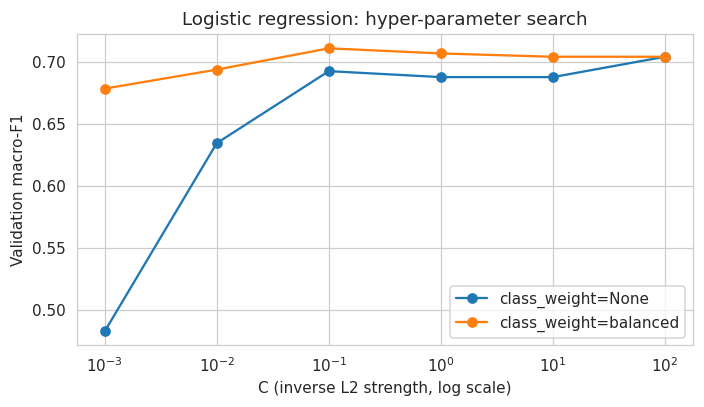

In [18]:
lr_results, lr_models = [], {}
for cw in [None, "balanced"]:
    for C in [0.001, 0.01, 0.1, 1, 10, 100]:
        lr = LogisticRegression(penalty="l2", C=C, class_weight=cw, solver="lbfgs", max_iter=2000, random_state=SEED)
        lr.fit(X_train, y_train)                                   # train on the training set
        m = evaluate(y_dev, lr.predict_proba(X_dev)[:, 1])         # score on the validation set
        lr_results.append({"class_weight": str(cw), "C": C, **{f"val_{k}": v for k, v in m.items()}})
        lr_models[(str(cw), C)] = lr

lr_val = pd.DataFrame(lr_results)
display(lr_val.round(4))

# model selection: best validation macro-F1 (AUC as tie-breaker)
best_row = lr_val.sort_values(["val_macro_f1", "val_auc"], ascending=False).iloc[0]
best_lr_key = (best_row["class_weight"], best_row["C"])
best_lr = lr_models[best_lr_key]
print(f"\nSelected logistic regression: class_weight={best_lr_key[0]}, C={best_lr_key[1]}  "
      f"(validation macro-F1 = {best_row['val_macro_f1']:.4f}, AUC = {best_row['val_auc']:.4f})")

# visualise the search
fig, ax = plt.subplots(figsize=(6.5, 3.8))
for cw, g in lr_val.groupby("class_weight"):
    ax.plot(g["C"], g["val_macro_f1"], marker="o", label=f"class_weight={cw}")
ax.set_xscale("log"); ax.set_xlabel("C (inverse L2 strength, log scale)"); ax.set_ylabel("Validation macro-F1")
ax.set_title("Logistic regression: hyper-parameter search"); ax.legend()
plt.tight_layout(); plt.show()

### 2b) Neural network (10 points)
A fully-connected feed-forward network (multi-layer perceptron, `sklearn.neural_network.MLPClassifier`): 128-d review embedding -> hidden layer(s) with **ReLU** -> 1 sigmoid output (probability of "positive"), trained with the **Adam** optimizer (learning rate 0.001, mini-batches of 64) to minimize the cross-entropy loss, with an L2 weight penalty `alpha`.

* `train_mlp()` trains **one epoch at a time** (`partial_fit`) and after every epoch records the training loss and the validation loss / macro-F1 / AUC. It keeps a copy of the network from the **best epoch (highest validation macro-F1)** and stops if there is no improvement for 10 epochs (**early stopping**).
* To handle the class imbalance, the option `oversample=True` randomly duplicates *training-set* negative reviews until both classes are equally frequent (`MLPClassifier` has no `class_weight` option).
* Hyper-parameters searched on the validation set: hidden layers `(64,)` or `(128, 64)`, `alpha` in {0.0001, 0.01}, `oversample` in {False, True} -> 8 configurations.

In [19]:
def oversample_minority(X, y, seed=SEED):
    """Randomly duplicate minority-class (negative) rows until both classes have equal size."""
    rng = np.random.RandomState(seed)
    neg, pos = np.where(y == 0)[0], np.where(y == 1)[0]
    extra = rng.choice(neg, size=len(pos) - len(neg), replace=True)    # extra negatives (with replacement)
    idx = np.concatenate([np.arange(len(y)), extra])
    return X[idx], y[idx]

def train_mlp(hidden, alpha, oversample, max_epochs=60, patience=10):
    """Train an MLP epoch by epoch; return (best model, per-epoch history DataFrame)."""
    Xtr, ytr = oversample_minority(X_train, y_train) if oversample else (X_train, y_train)
    clf = MLPClassifier(hidden_layer_sizes=hidden, activation="relu", solver="adam", alpha=alpha,
                        batch_size=64, learning_rate_init=1e-3, random_state=SEED)
    history, best, best_key, best_epoch = [], None, (-1, -1), 0
    for epoch in range(1, max_epochs + 1):
        clf.partial_fit(Xtr, ytr, classes=np.array([0, 1]))             # ONE pass over the training data
        p_dev = clf.predict_proba(X_dev)[:, 1]
        m = evaluate(y_dev, p_dev)
        history.append({"epoch": epoch, "train_loss": clf.loss_, "val_loss": log_loss(y_dev, p_dev),
                        "val_macro_f1": m["macro_f1"], "val_auc": m["auc"]})
        key = (m["macro_f1"], m["auc"])                                 # selection criterion
        if key > best_key:                                              # new best epoch -> keep a copy
            best, best_key, best_epoch = copy.deepcopy(clf), key, epoch
        if epoch - best_epoch >= patience:                              # early stopping
            break
    return best, pd.DataFrame(history), best_epoch

nn_results, nn_models, nn_hist = [], {}, {}
for hidden in [(64,), (128, 64)]:
    for alpha in [1e-4, 1e-2]:
        for os_flag in [False, True]:
            model, hist, ep = train_mlp(hidden, alpha, os_flag)
            m = evaluate(y_dev, model.predict_proba(X_dev)[:, 1])
            key = (str(hidden), alpha, os_flag)
            nn_models[key], nn_hist[key] = model, hist
            nn_results.append({"hidden": str(hidden), "alpha": alpha, "oversample": os_flag, "best_epoch": ep,
                               **{f"val_{k}": v for k, v in m.items()}})

nn_val = pd.DataFrame(nn_results)
display(nn_val.round(4))

best_nn_row = nn_val.sort_values(["val_macro_f1", "val_auc"], ascending=False).iloc[0]
best_nn_key = (best_nn_row["hidden"], best_nn_row["alpha"], best_nn_row["oversample"])
best_nn = nn_models[best_nn_key]
print(f"\nSelected neural network: hidden={best_nn_key[0]}, alpha={best_nn_key[1]}, oversample={best_nn_key[2]}, "
      f"best epoch={best_nn_row['best_epoch']}  (validation macro-F1 = {best_nn_row['val_macro_f1']:.4f}, AUC = {best_nn_row['val_auc']:.4f})")

,hidden,alpha,oversample,best_epoch,val_accuracy,val_precision,val_recall,val_f1,val_macro_f1,val_auc
0,"(64,)",0.0001,False,35,0.9539,0.9669,0.9843,0.9755,0.7913,0.9545
1,"(64,)",0.0001,True,19,0.9434,0.9707,0.9685,0.9696,0.7771,0.9533
2,"(64,)",0.0100,False,32,0.9539,0.9669,0.9843,0.9755,0.7913,0.9549
3,"(64,)",0.0100,True,23,0.9434,0.9707,0.9685,0.9696,0.7771,0.9559
4,"(128, 64)",0.0001,False,3,0.9560,0.9711,0.9820,0.9765,0.8103,0.9730
5,"(128, 64)",0.0001,True,3,0.9413,0.9728,0.9640,0.9684,0.7783,0.9615
6,"(128, 64)",0.0100,False,3,0.9560,0.9711,0.9820,0.9765,0.8103,0.9732
7,"(128, 64)",0.0100,True,3,0.9413,0.9728,0.9640,0.9684,0.7783,0.9611



Selected neural network: hidden=(128, 64), alpha=0.01, oversample=False, best epoch=3  (validation macro-F1 = 0.8103, AUC = 0.9732)


Learning curves of the selected network: training loss and validation loss per epoch (left) and validation macro-F1 / AUC per epoch (right). The dashed line marks the epoch that was kept.

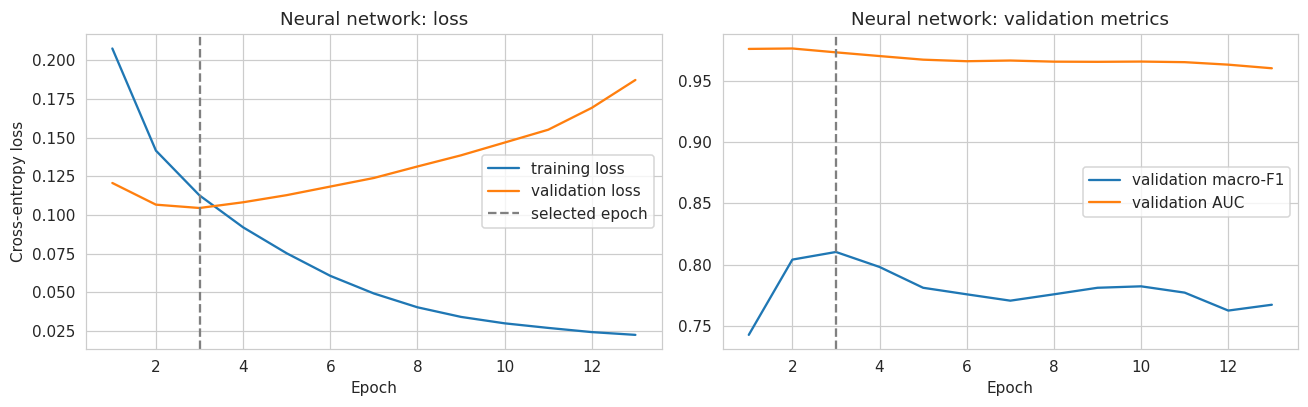

In [20]:
h = nn_hist[best_nn_key]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(h["epoch"], h["train_loss"], label="training loss")
axes[0].plot(h["epoch"], h["val_loss"], label="validation loss")
axes[0].axvline(best_nn_row["best_epoch"], color="gray", ls="--", label="selected epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-entropy loss"); axes[0].set_title("Neural network: loss"); axes[0].legend()
axes[1].plot(h["epoch"], h["val_macro_f1"], label="validation macro-F1")
axes[1].plot(h["epoch"], h["val_auc"], label="validation AUC")
axes[1].axvline(best_nn_row["best_epoch"], color="gray", ls="--")
axes[1].set_xlabel("Epoch"); axes[1].set_title("Neural network: validation metrics"); axes[1].legend()
plt.tight_layout(); plt.show()

### 3a) Evaluation on the test set (10 points)
The two selected models (one per family) are now evaluated **once** on the untouched **test set**. We report accuracy, precision, recall, F1 (positive class), macro-F1 and AUC in a table; a per-class report (so that the negative class is visible too); the confusion matrices; and the ROC curves.

In [21]:
p_test_lr = best_lr.predict_proba(X_test)[:, 1]
p_test_nn = best_nn.predict_proba(X_test)[:, 1]

res = pd.DataFrame({"Majority baseline (always positive)": majority_baseline,
                    "Logistic regression (L2)": evaluate(y_test, p_test_lr),
                    "Neural network (MLP)": evaluate(y_test, p_test_nn)}).T
res.columns = ["Accuracy", "Precision (pos.)", "Recall (pos.)", "F1 (pos.)", "Macro-F1", "AUC"]
print(f"TEST SET RESULTS (n = {len(y_test)}; {int((y_test==0).sum())} negative, {int((y_test==1).sum())} positive)")
display(res.round(4))

for name, p in [("Logistic regression (L2)", p_test_lr), ("Neural network (MLP)", p_test_nn)]:
    print(f"\n===== {name}: per-class report =====")
    print(classification_report(y_test, (p >= 0.5).astype(int), target_names=["negative", "positive"], digits=4, zero_division=0))

TEST SET RESULTS (n = 478; 33 negative, 445 positive)


,Accuracy,Precision (pos.),Recall (pos.),F1 (pos.),Macro-F1,AUC
Majority baseline (always positive),0.9310,0.9310,1.0000,0.9642,0.4821,0.5000
Logistic regression (L2),0.8808,0.9778,0.8921,0.9330,0.6951,0.9116
Neural network (MLP),0.9477,0.9646,0.9798,0.9721,0.7742,0.9049



===== Logistic regression (L2): per-class report =====
              precision    recall  f1-score   support

    negative     0.3333    0.7273    0.4571        33
    positive     0.9778    0.8921    0.9330       445

    accuracy                         0.8808       478
   macro avg     0.6556    0.8097    0.6951       478
weighted avg     0.9333    0.8808    0.9002       478


===== Neural network (MLP): per-class report =====
              precision    recall  f1-score   support

    negative     0.6538    0.5152    0.5763        33
    positive     0.9646    0.9798    0.9721       445

    accuracy                         0.9477       478
   macro avg     0.8092    0.7475    0.7742       478
weighted avg     0.9431    0.9477    0.9448       478



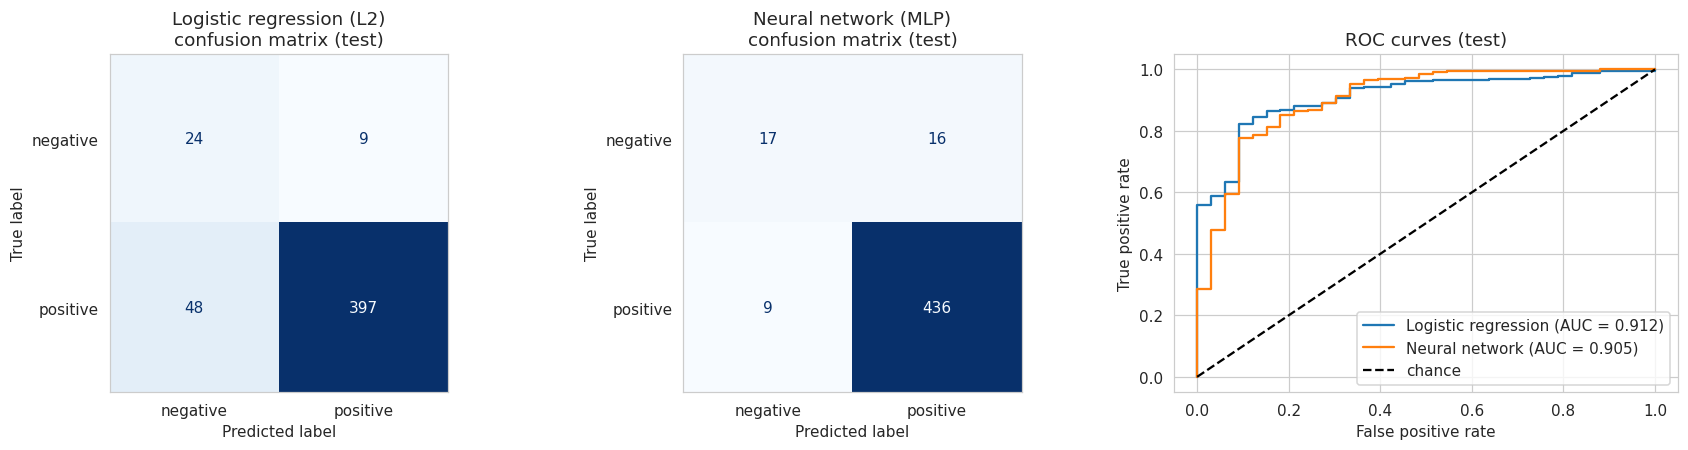

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# confusion matrices (rows = true class, columns = predicted class)
for ax, (name, p) in zip(axes[:2], [("Logistic regression (L2)", p_test_lr), ("Neural network (MLP)", p_test_nn)]):
    cm = confusion_matrix(y_test, (p >= 0.5).astype(int))
    ConfusionMatrixDisplay(cm, display_labels=["negative", "positive"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name}\nconfusion matrix (test)"); ax.grid(False)

# ROC curves
for name, p in [("Logistic regression", p_test_lr), ("Neural network", p_test_nn)]:
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[2].plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, p):.3f})")
axes[2].plot([0, 1], [0, 1], "k--", label="chance")
axes[2].set_xlabel("False positive rate"); axes[2].set_ylabel("True positive rate"); axes[2].set_title("ROC curves (test)"); axes[2].legend()
plt.tight_layout(); plt.show()

### 3b) Discussion: comparison of the two models (5 points)
_All statements below refer to the exact numbers produced by the cells above, with this seed and this split._

**Test-set results (n = 478: 33 negative, 445 positive)**

| | Accuracy | F1 (positive) | Macro-F1 | AUC | Negative-class precision / recall |
|---|---|---|---|---|---|
| Always-positive baseline | 0.931 | 0.964 | 0.482 | 0.500 | - / 0.000 |
| Logistic regression (L2, balanced, C = 0.1) | 0.881 | 0.933 | 0.695 | 0.912 | 0.333 / 0.727 |
| Neural network (128-64, early-stopped at epoch 3) | 0.948 | 0.972 | 0.774 | 0.905 | 0.654 / 0.515 |

**Discussion**

1. **Overall quality (threshold 0.5).** The neural network is better on accuracy (0.948 vs. 0.881), on the F1 of the positive class (0.972 vs. 0.933) and on macro-F1 (0.774 vs. 0.695). Both models are clearly better than the trivial baseline in macro-F1, but note that **the logistic regression's accuracy is *below* the 0.931 of the always-positive baseline**.
2. **Different trade-offs, not simply "better/worse".** Validation selected `class_weight="balanced"` for the logistic regression, which makes it care more about the rare negative class: it finds 24 of the 33 negative reviews (recall 0.727) but raises many false alarms - it labels 72 reviews negative, of which only 24 are (precision 0.333), and misclassifies 48 positive reviews. The network (no re-weighting) is more conservative: it flags 26 reviews as negative, 17 correctly (precision 0.654, recall 0.515). If the business goal is to *catch unhappy customers* and false alarms are cheap, the logistic regression's operating point is attractive; if overall correctness and a more precise negative list matter, the network is preferable.
3. **Ranking ability is essentially the same.** The threshold-free AUC is 0.912 (LR) vs. 0.905 (NN); the ROC curves cross, and a difference of 0.007 is well inside the noise to be expected with only 33 negative test reviews. So most of the gap in accuracy/F1 comes from the *decision threshold / class handling*, not from one model understanding the text better. (A threshold or class-weight adjustment of the network would move it along its ROC curve.)
4. **Why the non-linear network does not clearly win.** Both models see the same 128-dimensional *average* of GloVe vectors. Averaging discards word order and negation (and the stop-word list removed *not*/*no*), so the available information is limited and a linear model already captures most of it. The network also **overfits very quickly**: in the learning curves the validation loss is lowest around epochs 2-3 while the training loss keeps decreasing, so early stopping (best epoch = 3) was essential.
5. **Validation vs. test gap and limitations.** Validation AUCs (LR 0.948, NN 0.973) were higher than test AUCs (0.912 and 0.905). The validation set is small (32 negatives) and the best of 12 / 8 configurations was picked on it, so the validation scores are optimistic; the test numbers are the honest estimate. All results come from a single split and a single seed, without confidence intervals, so the differences above should be read as indicative rather than conclusive.
6. **Possible improvements** (not implemented, outside the assignment scope): keep negation words, use TF-IDF-weighted averages, cross-validation, threshold tuning, or domain-specific embeddings.

# Task 3: Self-reflection (5 points)
_Please enter your own answer index in the right-hand column - these are personal questions and must reflect your own opinion._

| Question | Answer (provide the answer index) |
|---|---|
| **Q1:** Rate your performance (1-Very unsatisfied, 2-Somewhat unsatisfied, 3-Neutral, 4-Somewhat satisfied, 5-Very satisfied) | **[YOUR ANSWER]** |
| **Q2:** How much does your understanding of the concepts influence your performance? (1-Very unimportant ... 5-Very important) | **[YOUR ANSWER]** |
| **Q3:** How much does the design of the examples/questions (is relatable to you) influence your performance? (1-Very unimportant ... 5-Very important) | **[YOUR ANSWER]** |
| **Q4:** Primary factors influencing the relatability of the examples to you? (1-Gender, 2-Race, 3-Age, 4-Culture background, 5-Socioeconomic status, 6-Hobbies and interests, 7-Prior knowledge about the context in the example, 8-Others - specify) | **[YOUR ANSWER]** |

**Comments / suggestions about Homework 1 (optional):** [YOUR COMMENTS]

# References and resources used
* Lecture slides: *Introduction*, *Machine Learning Basics*, *Vector Semantics* (CS 584, Ping Wang, Stevens Institute of Technology) - co-occurrence matrices, SVD, GloVe, logistic regression, evaluation.
* Pennington, Socher & Manning (2014). *GloVe: Global Vectors for Word Representation.* EMNLP. Vectors: `glove-wiki-gigaword-200` via the `gensim-data` repository.
* Libraries: NumPy, pandas, matplotlib, seaborn, NLTK (English stop-word list), scikit-learn (`TruncatedSVD`, `LogisticRegression`, `MLPClassifier`, metrics), gensim.
* `load_embedding_model()` and `get_matrix_of_vectors()` are taken from the assignment handout (the latter lightly adapted as stated in its description).
* **Generative-AI disclosure:** [EDIT THIS SENTENCE TO MATCH WHAT YOU ACTUALLY DID - e.g. "Claude (Anthropic) was used to help draft and explain the code in this notebook; I reviewed, ran and understood all of it."]